In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [88]:
df = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Intermship Project/retail_large_dataset EDA project.csv")
df.head()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
count,100000,100000.000000,100000,100000,100000,100000,100000,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000,100000.000000,100000
unique,100000,NaN,2,10,9,3,100000,1095,6,21,NaN,NaN,NaN,NaN,4,2,NaN,2
top,C10000,NaN,Male,Hyderabad,Maharashtra,New,O50000,12/04/2023,Health,Protein Powder,NaN,NaN,NaN,NaN,Credit Card,Express,NaN,No
freq,1,NaN,50111,10150,19952,33488,1,124,16858,5668,NaN,NaN,NaN,NaN,25307,50008,NaN,85189
mean,NaN,41.561830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30164.526720,2.501790,15.009890,64165.723382,NaN,NaN,5.505540,NaN
std,NaN,13.852439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17139.679807,1.120058,8.953296,49969.280150,NaN,NaN,2.872868,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.000000,1.000000,0.000000,357.000000,NaN,NaN,1.000000,NaN
25%,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15375.000000,1.000000,7.000000,24705.000000,NaN,NaN,3.000000,NaN
50%,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30148.000000,3.000000,15.000000,49752.390000,NaN,NaN,5.000000,NaN
75%,NaN,54.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44957.000000,4.000000,23.000000,94046.070000,NaN,NaN,8.000000,NaN


In [89]:
# Missing Value

df.isnull().sum()

customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method         0
shipping_type          0
delivery_days          0
return_status          0
dtype: int64

In [90]:
# duplicate values

df.duplicated().sum()
print("Total Duplicate Rows :",df.duplicated().sum())

Total Duplicate Rows : 0


In [91]:
# Check Data types

df.dtypes

customer_id             object
age                      int64
gender                  object
city                    object
state                   object
customer_segment        object
order_id                object
order_date              object
product_category        object
product_subcategory     object
product_price            int64
quantity                 int64
discount_percentage      int64
final_price            float64
payment_method          object
shipping_type           object
delivery_days            int64
return_status           object
dtype: object

In [92]:
df["order_date"].head()

0    10/05/2025
1    27/11/2023
2    08/02/2025
3    19/04/2024
4    08/10/2024
Name: order_date, dtype: object

In [174]:
# Univarite Analysis

numerical_columns = [
    'age',
    'product_price',
    'quantity',
    'discount_percentage',
    'final_price',
    'delivery_days'
]


In [176]:
# DESCRIPTIVE STATISTICS

summary = pd.DataFrame({
    'Metric': [
        'Average Age',
        'Average Product Price',
        'Average Quantity',
        'Average Discount'
    ],
    'Value': [
        df['age'].mean(),
        df['product_price'].mean(),
        df['quantity'].mean(),
        df['discount_percentage'].mean()
    ]
})

summary.round(2)

,Metric,Value
0,Average Age,41.56
1,Average Product Price,30164.53
2,Average Quantity,2.50
3,Average Discount,15.01


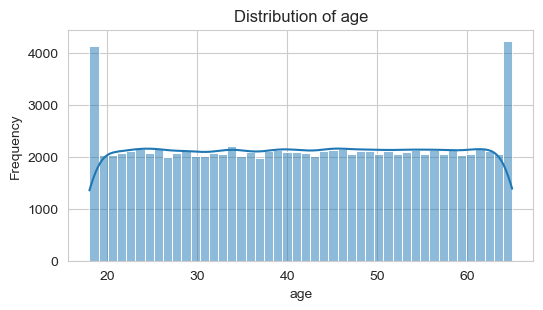

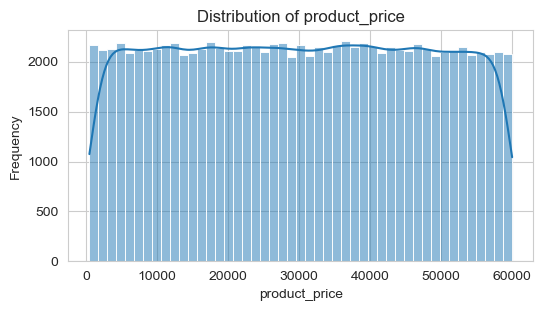

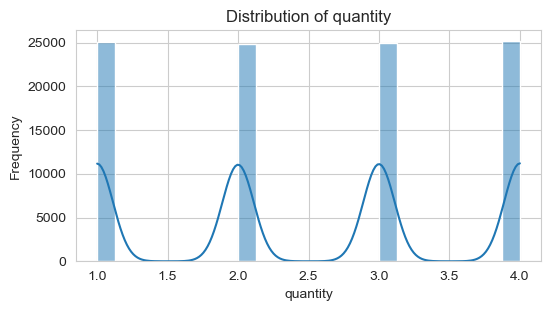

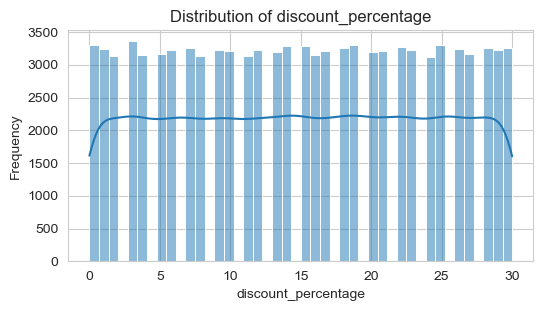

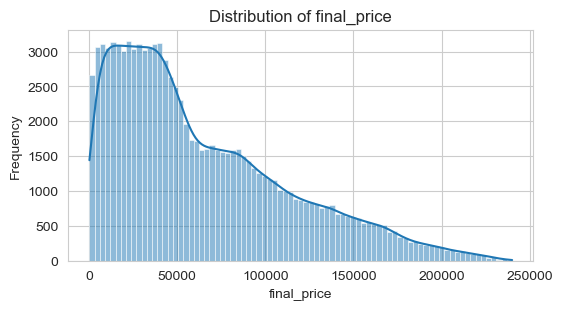

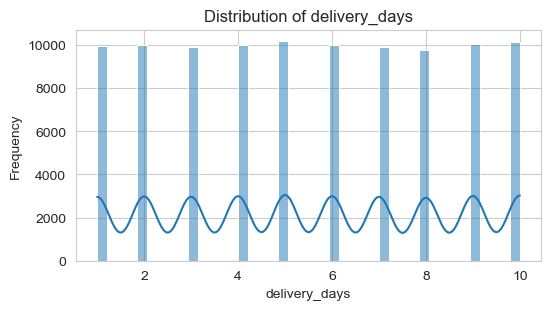

In [94]:
# Distrubution Graphs

for column in numerical_columns:
    plt.figure(figsize=(6, 3))
    
    sns.histplot(df[column], kde=True)
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    
    plt.show()

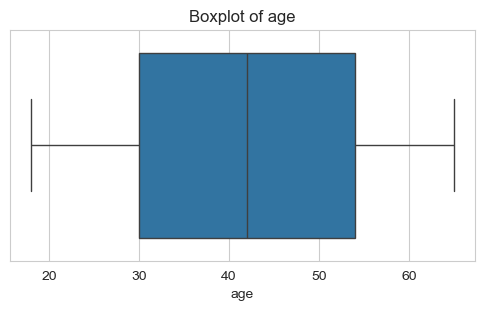

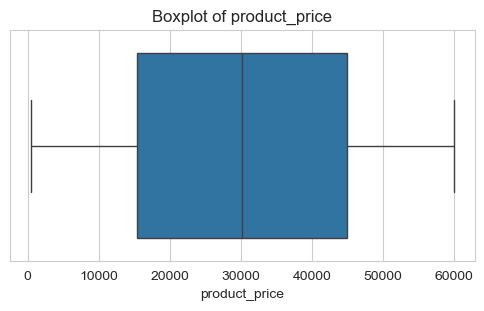

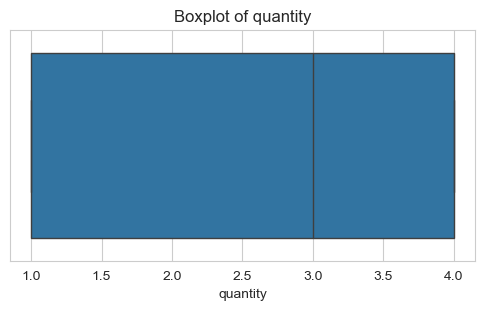

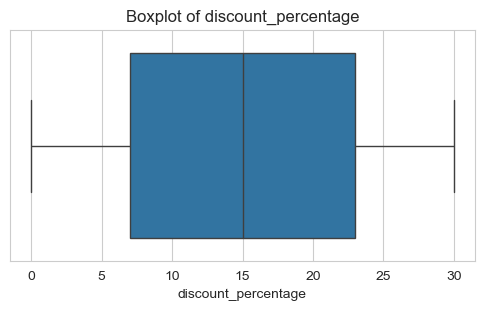

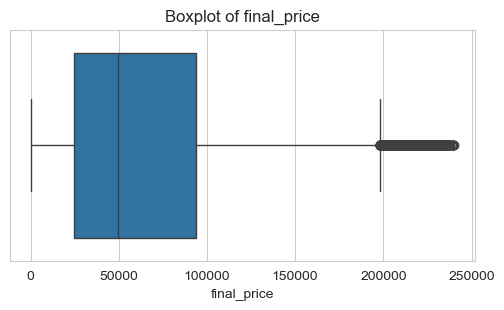

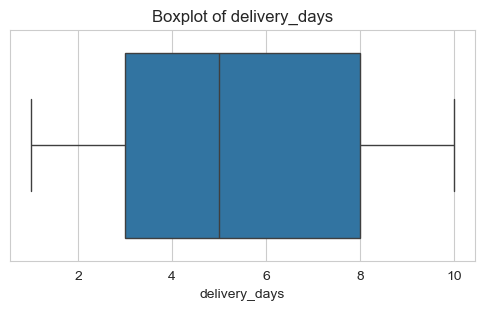

In [175]:
# outliers Detection BoxPlot

for column in numerical_columns:
    plt.figure(figsize=(6, 3))
    
    sns.boxplot(x=df[column])
    
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    
    plt.show()


In [96]:
# Outlier Detection IQR Method

outlier_summary = []

for column in numerical_columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_summary.append({
        'Variable': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,age,30.0,54.00,24.00,-6.000,90.000,0,0.000
1,product_price,15375.0,44957.00,29582.00,-28998.000,89330.000,0,0.000
2,quantity,1.0,4.00,3.00,-3.500,8.500,0,0.000
3,discount_percentage,7.0,23.00,16.00,-17.000,47.000,0,0.000
4,final_price,24705.0,94046.07,69341.07,-79306.605,198057.675,1335,1.335
5,delivery_days,3.0,8.00,5.00,-4.500,15.500,0,0.000


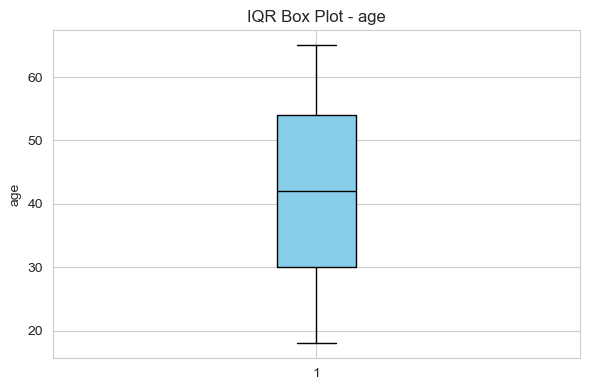

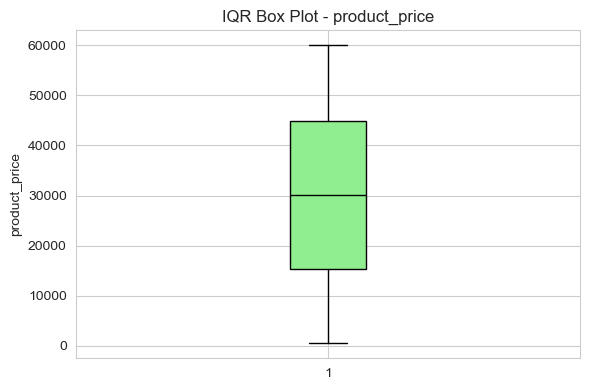

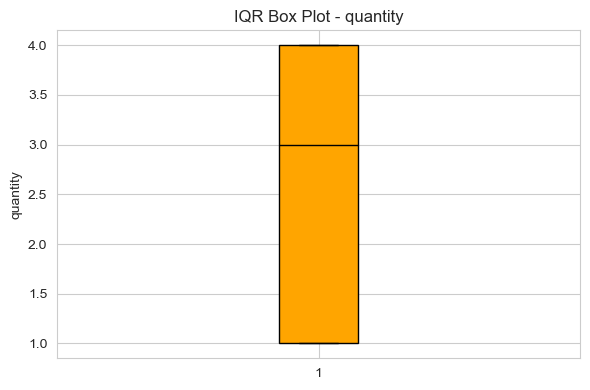

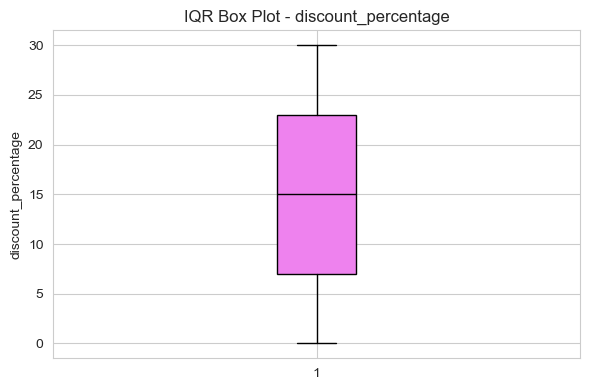

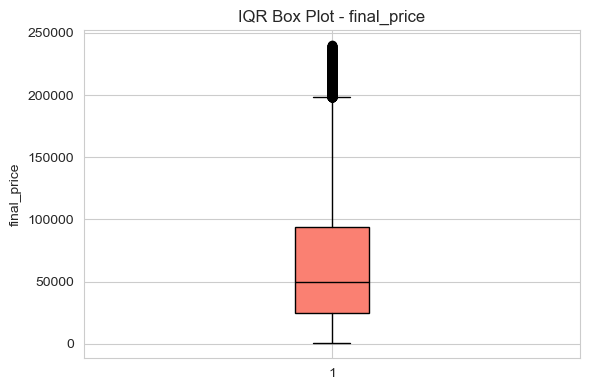

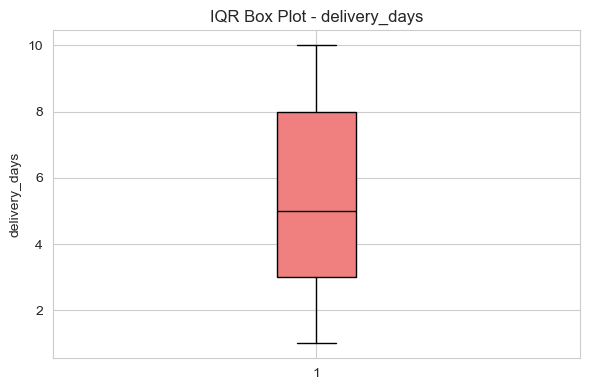

In [161]:
# IQR Box Plots

numerical_columns = [
    'age',
    'product_price',
    'quantity',
    'discount_percentage',
    'final_price',
    'delivery_days'
]

colors = [
    'skyblue',
    'lightgreen',
    'orange',
    'violet',
    'salmon',
    'lightcoral'
]

for col, color in zip(numerical_columns, colors):

    plt.figure(figsize=(6, 4))

    plt.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=color, color='black'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black')
    )

    plt.title(f'IQR Box Plot - {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

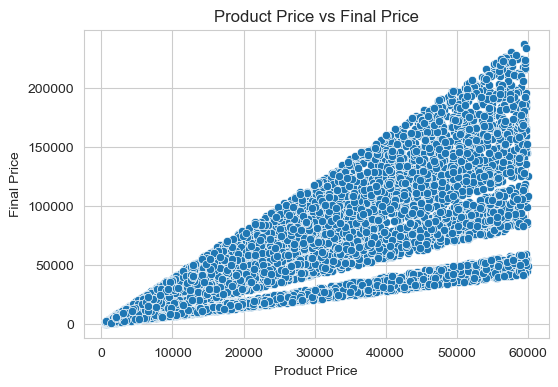

In [164]:
# Bivariate Analysis
# Product price Vs Final Price

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df.sample(7000, random_state=10),
    x='product_price',
    y='final_price'
)

plt.title('Product Price vs Final Price')
plt.xlabel('Product Price')
plt.ylabel('Final Price')
plt.show()



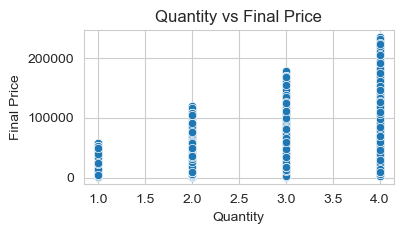

In [99]:
# Quantity And Final Price

plt.figure(figsize=(4,2))

sns.scatterplot(
    data=df.sample(6000, random_state=30),
    x='quantity',
    y='final_price'
)

plt.title('Quantity vs Final Price')
plt.xlabel('Quantity')
plt.ylabel('Final Price')
plt.show()


In [100]:
# Age and Spending

age_spending_corr = df['age'].corr(df['final_price'])

print("Correlation between Age and Final Price:", age_spending_corr)

Correlation between Age and Final Price: -0.0008232425708035182


In [101]:
# Delevery Day And Return Status

df['return_status'] = df['return_status'].map({
    'Not Returned': 0,
    'Returned': 1
})

In [102]:
delivery_return = df['delivery_days'].corr(
    df['return_status']
)

print("Correlation between Delivery Days and Return Status:",
      delivery_return)

Correlation between Delivery Days and Return Status: nan


In [103]:
# Segment vs Avg Price

seg_avg_price = df.groupby('customer_segment')['final_price'].mean()

seg_avg_price

customer_segment
New        63766.749294
Premium    64430.451339
Regular    64303.154748
Name: final_price, dtype: float64

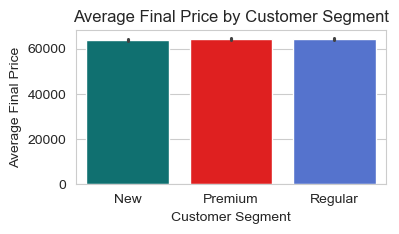

In [172]:
plt.figure(figsize=(4,2))
sns.barplot(data=df,x='customer_segment',y='final_price',estimator='mean', hue='customer_segment',
    palette=['teal', 'red', 'royalblue'],
    legend=False)
plt.title('Average Final Price by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Final Price')
plt.show()

In [105]:
# Product Category vs Return Rate

return_rate = pd.crosstab(df['product_category'],df['return_status'],normalize='index') * 100

return_rate

return_status
product_category


In [106]:
print(df[['product_category', 'return_status']].head(10))

  product_category  return_status
0           Health            NaN
1      Electronics            NaN
2          Fashion            NaN
3           Beauty            NaN
4           Beauty            NaN
5      Electronics            NaN
6          Grocery            NaN
7      Electronics            NaN
8           Health            NaN
9           Beauty            NaN


In [107]:
print(df['product_category'].unique())

['Health' 'Electronics' 'Fashion' 'Beauty' 'Grocery' 'Home & Kitchen']


In [108]:
print(df['return_status'].unique())

[nan]


In [109]:
#  Shipping Type vs Delivery Days

shipping_delivery = df.groupby('shipping_type')['delivery_days'].mean()

shipping_delivery


shipping_type
Express     5.497400
Standard    5.513682
Name: delivery_days, dtype: float64

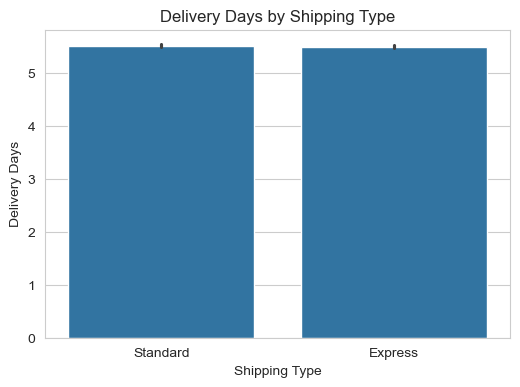

In [141]:
plt.figure(figsize=(6,4))
sns.barplot(data=df,x='shipping_type',y='delivery_days',estimator='mean')
plt.title('Delivery Days by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Delivery Days')
plt.show()

In [111]:
# Correlation Metrix Analysis

   ## Selecting the numerical columns ##

numeric_cols = ['age','product_price','quantity','discount_percentage','final_price','delivery_days']

In [112]:
corr_matrix = df[numeric_cols].corr()

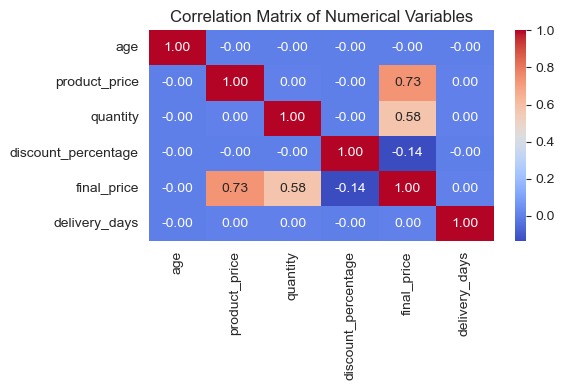

In [182]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

In [114]:
# Multivariate Analysis

# 1. Product Catagory x Discount x Final Price

category_discount_price = df.groupby('product_category')[['discount_percentage', 'final_price']].mean()

category_discount_price



,discount_percentage,final_price
product_category,,
Beauty,15.021195,64030.551411
Electronics,14.944196,64329.670769
Fashion,14.966171,64002.188248
Grocery,15.093238,64101.808490
Health,14.992051,63686.691925
Home & Kitchen,15.042320,64840.420692


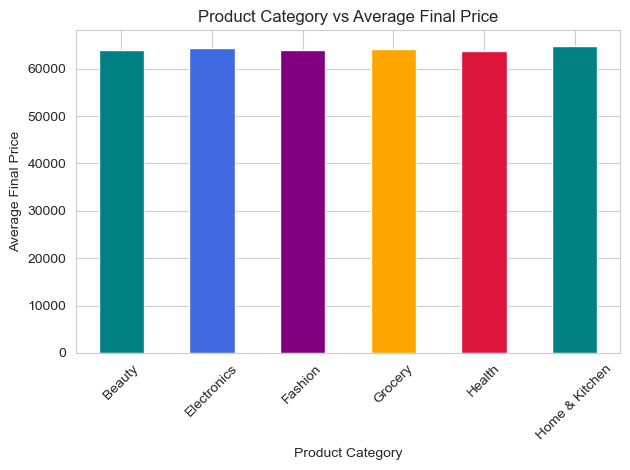

In [169]:
df.groupby('product_category')['final_price'].mean().plot(kind='bar',  color=['teal', 'royalblue', 'purple', 'orange', 'crimson'])
plt.title('Product Category vs Average Final Price')
plt.xlabel('Product Category')
plt.ylabel('Average Final Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [116]:
# 2. Custumer Segement x Age x Spending

segment_age = df.groupby(
    ['customer_segment', 'age']
)['final_price'].mean()

segment_age

customer_segment  age
New               18     62932.961697
                  19     67704.149448
                  20     63139.139323
                  21     65704.957447
                  22     61803.469074
                             ...     
Regular           61     68413.301676
                  62     61636.815676
                  63     62133.647351
                  64     67333.531583
                  65     63777.911165
Name: final_price, Length: 144, dtype: float64

In [117]:
# But because there are many individual ages, it is easier to create age groups:

df['age_group'] = pd.cut(df['age'],bins=[0, 29, 45, 60, 100],labels=['Below 30', '30-45', '46-60', '60+'])

In [118]:
# Which customer segment and age group has the highest average final price?

segment_age = df.groupby(
    ['customer_segment', 'age_group'],
    observed=True
)['final_price'].mean()

segment_age

customer_segment  age_group
New               Below 30     63715.337696
                  30-45        64033.116897
                  46-60        63646.726198
                  60+          63403.568825
Premium           Below 30     64012.797617
                  30-45        64827.724200
                  46-60        64329.228167
                  60+          64476.867838
Regular           Below 30     64252.133446
                  30-45        64148.958249
                  46-60        64381.631823
                  60+          64674.226006
Name: final_price, dtype: float64

# 3. Delivery Days × Shipping Type × Return Status

# there is no return information available to calculate return probability.

# Because Return Value Is NAN.

In [125]:
# Skewness Interpretation

skewness = df[
    [
        'age',
        'product_price',
        'quantity',
        'discount_percentage',
        'final_price',
        'delivery_days'
    ]
].skew()

skewness_table = pd.DataFrame({
    'Variable': skewness.index,
    'Skewness': skewness.round(4).values,
    'Interpretation': [
        'Approximately symmetric' if abs(x) <= 0.5
        else 'Positively skewed' if x > 0
        else 'Negatively skewed'
        for x in skewness
    ]
})

skewness_table

,Variable,Skewness,Interpretation
0,age,-0.0050,Approximately symmetric
1,product_price,0.0032,Approximately symmetric
2,quantity,-0.0031,Approximately symmetric
3,discount_percentage,-0.0036,Approximately symmetric
4,final_price,0.9347,Positively skewed
5,delivery_days,0.0023,Approximately symmetric


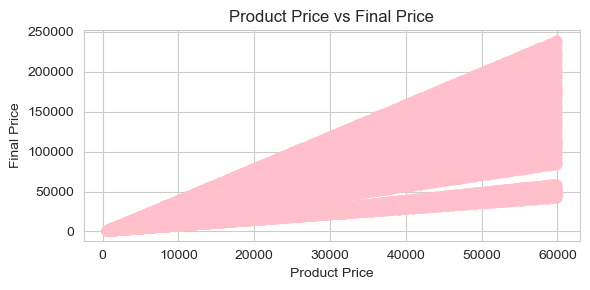

In [181]:
# Skewness Plot

plt.figure(figsize=(6, 3))
plt.scatter(df['product_price'], df['final_price'], alpha=0.5, color='pink')
plt.title('Product Price vs Final Price')
plt.xlabel('Product Price')
plt.ylabel('Final Price')
plt.tight_layout()
plt.show()

In [143]:
# Kurtosis Interpretation

numerical_columns = ['age','product_price','quantity','discount_percentage','final_price','delivery_days']

kurtosis = df[numerical_columns].kurt()

kurtosis_table = pd.DataFrame({
    'Variable': kurtosis.index,
    'Kurtosis': kurtosis.round(4).values,
    'Interpretation': [
        'Low / Light-tailed' if x < -0.5
        else 'Approximately normal' if x <= 0.5
        else 'High / Heavy-tailed'
        for x in kurtosis
    ]
})

kurtosis_table

,Variable,Kurtosis,Interpretation
0,age,-1.2012,Low / Light-tailed
1,product_price,-1.1951,Low / Light-tailed
2,quantity,-1.3646,Low / Light-tailed
3,discount_percentage,-1.2016,Low / Light-tailed
4,final_price,0.1690,Approximately normal
5,delivery_days,-1.2215,Low / Light-tailed


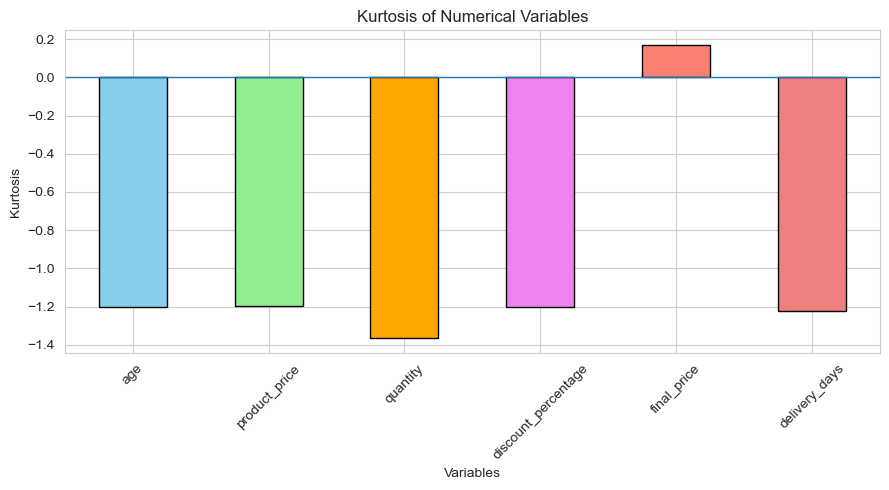

In [184]:
# Kurtosis Interpretation Plot

plt.figure(figsize=(9, 5))
colors = ['skyblue','lightgreen','orange','violet','salmon','lightcoral']
kurtosis.plot(kind='bar', color=colors,edgecolor='black')
plt.axhline(0, linewidth=1)
plt.title('Kurtosis of Numerical Variables')
plt.xlabel('Variables')
plt.ylabel('Kurtosis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [147]:
# Key Statical Finding

key_findings = pd.DataFrame({
    'Key Statistical Finding': [
        'final_price is positively (right) skewed',
        'Some transactions have relatively high final prices',
        '503 IQR-based outliers were detected in final_price',
        'Most numerical variables are approximately symmetric',
        'final_price kurtosis is approximately normal',
        'return_status is 100% missing',
        'Return probability could not be reliably analyzed'
    ]
})

key_findings

,Key Statistical Finding
0,final_price is positively (right) skewed
1,Some transactions have relatively high final p...
2,503 IQR-based outliers were detected in final_...
3,Most numerical variables are approximately sym...
4,final_price kurtosis is approximately normal
5,return_status is 100% missing
6,Return probability could not be reliably analyzed


In [173]:
# Conclusion

print("=" * 60)
print("                    CONCLUSION")
print("=" * 60)

print("\nThe Exploratory Data Analysis provided useful insights")
print("into the retail dataset.")

print("\n• Most numerical variables showed approximately symmetric")
print("  distributions.")

print("\n• final_price showed noticeable positive skewness.")

print("\n• 503 potential outliers were identified in final_price.")

print("\n• Correlation analysis helped identify relationships")
print("  among important numerical variables.")

print("\n• return_status was 100% missing, so return analysis")
print("  could not be reliably performed.")

print("\nOverall, the analysis helped understand purchasing patterns,")
print("transaction behavior, and potential high-value purchases.")

                    CONCLUSION

The Exploratory Data Analysis provided useful insights
into the retail dataset.

• Most numerical variables showed approximately symmetric
  distributions.

• final_price showed noticeable positive skewness.

• 503 potential outliers were identified in final_price.

• Correlation analysis helped identify relationships
  among important numerical variables.

• return_status was 100% missing, so return analysis
  could not be reliably performed.

Overall, the analysis helped understand purchasing patterns,
transaction behavior, and potential high-value purchases.
